# FactoryMind AI — Anomaly Detection Model Finalization

This notebook freezes the Anomaly Detection v1 research specification and defines its future guarded production-code contract. It fits one final development detector only; it does not tune, compare models, use official test labels, serialize artifacts, or claim industrial readiness.

## 1. Frozen Research Contract

The selected model is a raw-sensor Isolation Forest. It learns only from FD001 observations in the retrospective early-life reference region (`raw_rul > 125`). Raw RUL constructs that development subset but is never a predictor and will not be required during production inference.

The user-facing anomaly percentile is unusualness relative to the fitted development normal-reference distribution. It is not anomaly probability, failure probability, or a safety judgment.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = Path("../data/raw/train_FD001.txt")
NORMAL_REFERENCE_CUTOFF = 125
THRESHOLD_QUANTILE = 0.975
PERSISTENCE_WINDOW = 5
PERSISTENCE_REQUIRED = 3
RANDOM_STATE = 42
MODEL_VERSION = "1.0.0"
COLUMNS = (["unit_id", "cycle"] + [f"operational_setting_{i}" for i in range(1, 4)] + [f"sensor_{i}" for i in range(1, 22)])
PREDICTOR_COLUMNS = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8", "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15", "sensor_17", "sensor_20", "sensor_21"]
IF_HYPERPARAMETERS = {
    "n_estimators": 300, "max_samples": "auto", "contamination": "auto",
    "max_features": 1.0, "bootstrap": False, "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
WARNING = ("Anomaly does not mean failure. Unusual sensor behavior may reflect degradation, "
           "operating variation, noise, or other causes and should be investigated in context.")
DISCLAIMER = ("Development-stage condition-monitoring estimate based on simulated NASA C-MAPSS "
              "FD001 data with one operating condition and one fault mode, a retrospective healthy-reference "
              "assumption, and no validated real-world anomaly labels. Not an industrial safety decision.")
print("Frozen predictors:", PREDICTOR_COLUMNS)
print("Isolation Forest parameters:", IF_HYPERPARAMETERS)

Frozen predictors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Isolation Forest parameters: {'n_estimators': 300, 'max_samples': 'auto', 'contamination': 'auto', 'max_features': 1.0, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}


## 2. Load, Validate, and Construct Final Normal Reference

All 100 FD001 training units are development data. The final detector is fitted only on their rows with retrospective `raw_rul > 125`. This maximizes the available development normal-reference population without treating degraded rows as normal.

In [2]:
df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMNS)
df["raw_rul"] = df.groupby("unit_id")["cycle"].transform("max") - df["cycle"]
normal_reference = df[df.raw_rul > NORMAL_REFERENCE_CUTOFF].copy()

assert len(df) == 20_631 and df.unit_id.nunique() == 100
assert len(PREDICTOR_COLUMNS) == 14
assert PREDICTOR_COLUMNS == [c for c in COLUMNS if c in PREDICTOR_COLUMNS]
assert not {"unit_id", "cycle", "raw_rul", "RUL", "capped_rul", "final_lifetime", "failure"}.intersection(PREDICTOR_COLUMNS)
assert set(normal_reference.unit_id).issubset(set(df.unit_id))

print(f"Full FD001 development data: {len(df):,} observations, {df.unit_id.nunique()} units")
print(f"Final normal reference: {len(normal_reference):,} observations, {normal_reference.unit_id.nunique()} contributing units")
display(normal_reference[PREDICTOR_COLUMNS].describe().T[["mean", "std", "min", "max"]].round(4))

Full FD001 development data: 20,631 observations, 100 units
Final normal reference: 8,031 observations, 100 contributing units


,mean,std,min,max
sensor_2,642.3981,0.3740,641.2100,643.8000
sensor_3,1587.1764,4.6528,1571.0400,1604.3600
sensor_4,1403.1424,5.8903,1382.2500,1422.9700
sensor_7,553.9190,0.6147,551.8200,556.0600
sensor_8,2388.0593,0.0538,2387.9000,2388.2400
sensor_9,9057.3112,8.4243,9031.9700,9085.6900
sensor_11,47.3654,0.1727,46.8500,47.8700
sensor_12,521.8807,0.4966,520.1900,523.3800
sensor_13,2388.0583,0.0543,2387.8900,2388.2400
sensor_14,8138.4008,7.9457,8114.5000,8161.8200


## 3. Freeze Preprocessing and Isolation Forest

One `StandardScaler` is fitted only on final normal-reference observations, preserving the exact sensor order. Its `mean_` and `scale_` are also the authoritative reference statistics for sensor-deviation context. The Isolation Forest then fits only the scaled reference matrix.

Scikit-learn's `score_samples` is larger for more normal states, so the frozen transformation is:

`raw_anomaly_score = -detector.score_samples(scaled_input)`

Therefore larger values always mean more anomalous.

In [3]:
scaler = StandardScaler().fit(normal_reference[PREDICTOR_COLUMNS])
x_normal = scaler.transform(normal_reference[PREDICTOR_COLUMNS])
detector = IsolationForest(**IF_HYPERPARAMETERS).fit(x_normal)
normal_scores = -detector.score_samples(x_normal)

assert scaler.n_samples_seen_ == len(normal_reference)
assert detector.n_features_in_ == len(PREDICTOR_COLUMNS)
scaler_contract = pd.DataFrame({"sensor": PREDICTOR_COLUMNS, "reference_mean": scaler.mean_, "reference_scale": scaler.scale_})
display(scaler_contract.round(6))
print("Detector fitted on normal-reference matrix only:", x_normal.shape)

,sensor,reference_mean,reference_scale
0,sensor_2,642.398146,0.374013
1,sensor_3,1587.176424,4.652478
2,sensor_4,1403.142411,5.889948
3,sensor_7,553.919029,0.614675
4,sensor_8,2388.059295,0.053822
5,sensor_9,9057.311153,8.423802
6,sensor_11,47.365443,0.172682
7,sensor_12,521.880682,0.496597
8,sensor_13,2388.058312,0.054320
9,sensor_14,8138.400817,7.945179


Detector fitted on normal-reference matrix only: (8031, 14)


## 4. Final Training-Normal Score Distribution and Boundary

The exact v1 development alert boundary is derived from this final fitted model's own full-reference scores. It may differ from notebook 12's median repeated-split threshold because those models saw different subsets of engines and normal rows.

In [4]:
score_summary = pd.Series({
    "min": normal_scores.min(), "median": np.median(normal_scores), "mean": normal_scores.mean(),
    "std": normal_scores.std(ddof=1), "p90": np.quantile(normal_scores, .90),
    "p95": np.quantile(normal_scores, .95), "p97_5": np.quantile(normal_scores, .975),
    "p99": np.quantile(normal_scores, .99), "max": normal_scores.max(),
}, name="training_normal_anomaly_score")
FINAL_RAW_THRESHOLD = float(score_summary["p97_5"])
display(score_summary.to_frame().round(6))
print(f"Frozen final 97.5th-percentile raw boundary: {FINAL_RAW_THRESHOLD:.8f}")

,training_normal_anomaly_score
min,0.381468
median,0.444807
mean,0.448824
std,0.031442
p90,0.491689
p95,0.505947
p97_5,0.519717
p99,0.536312
max,0.610363


Frozen final 97.5th-percentile raw boundary: 0.51971655


## 5. Freeze the Empirical 0–100 Mapping

The deterministic empirical CDF uses right-inclusive rank:

`100 × count(reference_score <= current_score) / reference_count`

Consequences:

- below the minimum reference score → 0;
- equal to a reference score → includes all tied reference values at that score;
- above the maximum → 100.

This produces a bounded unusualness percentile and handles ties deterministically. It is not smoothed or calibrated as probability.

In [5]:
SORTED_NORMAL_SCORES = np.sort(normal_scores.copy())

def empirical_anomaly_percentile(raw_scores):
    values = np.asarray(raw_scores, dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("Anomaly scores must be finite.")
    percentiles = 100.0 * np.searchsorted(SORTED_NORMAL_SCORES, values, side="right") / len(SORTED_NORMAL_SCORES)
    return np.clip(percentiles, 0.0, 100.0)

edge_tests = pd.DataFrame({
    "case": ["below minimum", "minimum", "median reference value", "maximum", "above maximum"],
    "raw_score": [SORTED_NORMAL_SCORES[0]-1, SORTED_NORMAL_SCORES[0], SORTED_NORMAL_SCORES[len(SORTED_NORMAL_SCORES)//2], SORTED_NORMAL_SCORES[-1], SORTED_NORMAL_SCORES[-1]+1],
})
edge_tests["percentile"] = empirical_anomaly_percentile(edge_tests.raw_score)
display(edge_tests.round(6))
assert edge_tests.percentile.iloc[0] == 0 and edge_tests.percentile.iloc[-1] == 100
assert np.isclose(empirical_anomaly_percentile([FINAL_RAW_THRESHOLD])[0], 97.5, atol=.05)

,case,raw_score,percentile
0,below minimum,-0.618532,0.000000
1,minimum,0.381468,0.012452
2,median reference value,0.444807,50.006226
3,maximum,0.610363,100.000000
4,above maximum,1.610363,100.000000


## 6. Notebook Reference: Single-Observation Inference

`score_observation` accepts exactly the 14 finite numeric sensors. Targets, RUL, identity, cycle, missing fields, and extras are rejected. It returns the raw score, empirical percentile, strict boundary exceedance, and deterministic standardized sensor deviations.

In [6]:
def _validated_sensor_frame(sensor_row):
    if isinstance(sensor_row, pd.Series):
        sensor_row = sensor_row.to_dict()
    if not isinstance(sensor_row, dict):
        raise TypeError("Observation must be a mapping of the 14 required sensors.")
    supplied, required = set(sensor_row), set(PREDICTOR_COLUMNS)
    if supplied != required:
        missing, extra = sorted(required-supplied), sorted(supplied-required)
        raise ValueError(f"Sensor contract mismatch; missing={missing}, extra={extra}")
    if any(isinstance(sensor_row[c], (bool, np.bool_)) for c in PREDICTOR_COLUMNS): raise ValueError("Boolean sensor values are not accepted.")
    frame = pd.DataFrame([[sensor_row[c] for c in PREDICTOR_COLUMNS]], columns=PREDICTOR_COLUMNS)
    try: frame = frame.astype(float)
    except (TypeError, ValueError) as exc: raise ValueError("All sensor values must be numeric.") from exc
    if not np.isfinite(frame.to_numpy()).all(): raise ValueError("All sensor values must be finite.")
    return frame

def score_observation(sensor_row, top_n=5):
    frame = _validated_sensor_frame(sensor_row)
    scaled = scaler.transform(frame)[0]
    raw_score = float(-detector.score_samples(scaled.reshape(1, -1))[0])
    percentile = float(empirical_anomaly_percentile([raw_score])[0])
    values = frame.iloc[0].to_numpy()
    order = np.argsort(np.abs(scaled))[::-1][:top_n]
    deviations = [{"sensor": PREDICTOR_COLUMNS[i], "current_value": float(values[i]),
                   "reference_mean": float(scaler.mean_[i]), "standardized_deviation": float(scaled[i]),
                   "direction": "above_normal" if scaled[i] >= 0 else "below_normal"} for i in order]
    return {"current_anomaly_score": raw_score, "anomaly_percentile": percentile,
            "current_threshold_exceeded": bool(raw_score > FINAL_RAW_THRESHOLD),
            "top_sensor_deviations": deviations}

example_single = score_observation(df.iloc[0][PREDICTOR_COLUMNS].to_dict(), top_n=3)
display(example_single)
for invalid in [dict(df.iloc[0][PREDICTOR_COLUMNS].to_dict(), raw_rul=100),
                {k:v for k,v in df.iloc[0][PREDICTOR_COLUMNS].to_dict().items() if k != "sensor_2"}]:
    try: score_observation(invalid); raise AssertionError("Invalid contract accepted")
    except ValueError: pass
print("Strict single-observation validation passed.")

{'current_anomaly_score': 0.433757087035629,
 'anomaly_percentile': 35.10148175818703,
 'current_threshold_exceeded': False,
 'top_sensor_deviations': [{'sensor': 'sensor_2',
   'current_value': 641.82,
   'reference_mean': 642.3981459345038,
   'standardized_deviation': -1.5457908473542517,
   'direction': 'below_normal'},
  {'sensor': 'sensor_9',
   'current_value': 9046.19,
   'reference_mean': 9057.311153032002,
   'standardized_deviation': -1.3202058547664348,
   'direction': 'below_normal'},
  {'sensor': 'sensor_20',
   'current_value': 39.06,
   'reference_mean': 38.92409662557589,
   'standardized_deviation': 1.0478991628357377,
   'direction': 'above_normal'}]}

Strict single-observation validation passed.


## 7. Notebook Reference: Trajectory Inference and Persistence

Input contains `cycle`, the exact 14 sensors, and optionally `unit_id` for identity only. Cycles must already be positive, integer, unique, strictly increasing, and consecutive; the function never reorders or fabricates history.

Persistence semantics are frozen:

- 1–4 available cycles: scores and threshold exceedance are available, but `persistence_status='insufficient_history'` and `alert_active=False`.
- 5+ cycles: inspect exactly the latest five; alert when at least three exceed the boundary.

The current state and persistent alert are separate concepts. No unsupported Low/Medium/High/Critical anomaly categories are introduced.

In [7]:
def _validate_trajectory(trajectory):
    if not isinstance(trajectory, pd.DataFrame) or trajectory.empty: raise ValueError("Trajectory must contain at least one observation.")
    allowed = set(["cycle"] + PREDICTOR_COLUMNS + (["unit_id"] if "unit_id" in trajectory else []))
    if set(trajectory.columns) != allowed: raise ValueError(f"Trajectory columns must be cycle, the 14 sensors, and optional unit_id; received extras/missing fields.")
    if "unit_id" in trajectory and trajectory.unit_id.nunique(dropna=False) != 1: raise ValueError("Trajectory must describe exactly one unit.")
    cycles = trajectory.cycle.to_numpy()
    if not np.issubdtype(cycles.dtype, np.number) or not np.isfinite(cycles.astype(float)).all(): raise ValueError("Cycles must be finite integers.")
    if not np.equal(cycles, np.floor(cycles)).all() or (cycles <= 0).any(): raise ValueError("Cycles must be positive integers.")
    if len(np.unique(cycles)) != len(cycles): raise ValueError("Cycles must be unique.")
    if len(cycles) > 1 and (np.diff(cycles) != 1).any(): raise ValueError("Cycles must be strictly increasing and consecutive; input is not reordered.")
    sensor_frame = trajectory[PREDICTOR_COLUMNS]
    if any(isinstance(value, (bool, np.bool_)) for value in sensor_frame.to_numpy().ravel()): raise ValueError("Boolean sensor values are not accepted.")
    try: sensor_frame = sensor_frame.astype(float)
    except (TypeError, ValueError) as exc: raise ValueError("All sensor values must be numeric.") from exc
    if not np.isfinite(sensor_frame.to_numpy()).all(): raise ValueError("All sensor values must be finite.")
    return sensor_frame

def evaluate_anomaly_trajectory(trajectory, top_n=5):
    sensor_frame = _validate_trajectory(trajectory)
    scaled = scaler.transform(sensor_frame)
    raw_scores = -detector.score_samples(scaled)
    percentiles = empirical_anomaly_percentile(raw_scores)
    exceedances = raw_scores > FINAL_RAW_THRESHOLD
    history_count = len(trajectory)
    recent = exceedances[-min(PERSISTENCE_WINDOW, history_count):]
    sufficient = history_count >= PERSISTENCE_WINDOW
    recent_count = int(recent.sum())
    latest = score_observation(sensor_frame.iloc[-1].to_dict(), top_n=top_n)
    return {**latest, "threshold_percentile": THRESHOLD_QUANTILE*100,
            "recent_window_size": len(recent), "recent_exceedance_pattern": recent.tolist(),
            "recent_exceedance_count": recent_count, "persistence_required_count": PERSISTENCE_REQUIRED,
            "persistence_window_size": PERSISTENCE_WINDOW,
            "persistence_status": "evaluated" if sufficient else "insufficient_history",
            "alert_active": bool(sufficient and recent_count >= PERSISTENCE_REQUIRED),
            "history_cycle_count": history_count,
            "model_version": MODEL_VERSION, "dataset": "NASA C-MAPSS FD001", "development_stage": True,
            "warning": WARNING, "disclaimer": DISCLAIMER}

short_result = evaluate_anomaly_trajectory(df[df.unit_id==1].head(4)[["cycle"]+PREDICTOR_COLUMNS])
assert short_result["persistence_status"] == "insufficient_history" and short_result["alert_active"] is False
five_result = evaluate_anomaly_trajectory(df[df.unit_id==1].head(5)[["cycle"]+PREDICTOR_COLUMNS])
assert five_result["persistence_status"] == "evaluated"
print("Short history:", {k:short_result[k] for k in ["history_cycle_count","anomaly_percentile","current_threshold_exceeded","persistence_status","alert_active"]})
print("Five cycles:", {k:five_result[k] for k in ["history_cycle_count","recent_exceedance_pattern","recent_exceedance_count","persistence_status","alert_active"]})

Short history: {'history_cycle_count': 4, 'anomaly_percentile': 74.08790935126385, 'current_threshold_exceeded': False, 'persistence_status': 'insufficient_history', 'alert_active': False}
Five cycles: {'history_cycle_count': 5, 'recent_exceedance_pattern': [False, False, False, False, False], 'recent_exceedance_count': 0, 'persistence_status': 'evaluated', 'alert_active': False}


## 8. Representative Inference Validation

A single mechanically selected unit—the unit closest to median final lifetime—is evaluated at fixed retrospective RUL targets representing early, degrading, near-failure, and critical stages. Selection is based on lifetime and lifecycle position, never anomaly score.

In [8]:
lifetimes = df.groupby("unit_id").cycle.max()
median_unit = int((lifetimes-lifetimes.median()).abs().idxmin())
unit_history = df[df.unit_id==median_unit]
targets = {"Early healthy":150, "Degrading":90, "Near failure":45, "Critical late life":15}
representative_rows=[]; representative_deviations=[]
for stage,target_rul in targets.items():
    target_index=(unit_history.raw_rul-target_rul).abs().idxmin()
    target_cycle=int(df.loc[target_index,"cycle"])
    trajectory=unit_history[unit_history.cycle<=target_cycle][["unit_id","cycle"]+PREDICTOR_COLUMNS]
    result=evaluate_anomaly_trajectory(trajectory,top_n=3)
    representative_rows.append({"stage":stage,"unit_id":median_unit,"cycle":target_cycle,"raw_rul_evaluation":int(df.loc[target_index,"raw_rul"]),
        **{k:result[k] for k in ["anomaly_percentile","current_threshold_exceeded","recent_exceedance_count","persistence_status","alert_active"]}})
    for item in result["top_sensor_deviations"]: representative_deviations.append({"stage":stage,**item})
display(pd.DataFrame(representative_rows).round(3))
display(pd.DataFrame(representative_deviations).round(3))

,stage,unit_id,cycle,raw_rul_evaluation,anomaly_percentile,current_threshold_exceeded,recent_exceedance_count,persistence_status,alert_active
0,Early healthy,26,49,150,89.316,False,1,evaluated,False
1,Degrading,26,109,90,83.103,False,0,evaluated,False
2,Near failure,26,154,45,99.975,True,5,evaluated,True
3,Critical late life,26,184,15,100.000,True,5,evaluated,True


,stage,sensor,current_value,reference_mean,standardized_deviation,direction
0,Early healthy,sensor_20,38.64,38.924,-2.191,below_normal
1,Early healthy,sensor_14,8122.01,8138.401,-2.063,below_normal
2,Early healthy,sensor_3,1594.99,1587.176,1.679,above_normal
3,Degrading,sensor_11,47.74,47.365,2.169,above_normal
4,Degrading,sensor_8,2388.17,2388.059,2.057,above_normal
5,Degrading,sensor_4,1412.41,1403.142,1.573,above_normal
6,Near failure,sensor_9,9086.74,9057.311,3.494,above_normal
7,Near failure,sensor_4,1422.94,1403.142,3.361,above_normal
8,Near failure,sensor_12,520.56,521.881,-2.659,below_normal
9,Critical late life,sensor_9,9124.85,9057.311,8.018,above_normal


## 9. Final Development Diagnostics

These diagnostics reuse the same FD001 development trajectories that defined the final detector. They are not independent validation and must not be used to retune the frozen boundary or policy.

In [9]:
all_scaled = scaler.transform(df[PREDICTOR_COLUMNS])
df_scored = df[["unit_id","cycle","raw_rul"]].copy()
df_scored["raw_score"] = -detector.score_samples(all_scaled)
df_scored["percentile"] = empirical_anomaly_percentile(df_scored.raw_score)
df_scored["threshold_exceeded"] = df_scored.raw_score > FINAL_RAW_THRESHOLD
df_scored["persistent_alert"] = (df_scored.groupby("unit_id").threshold_exceeded
    .transform(lambda x: x.rolling(PERSISTENCE_WINDOW, min_periods=PERSISTENCE_WINDOW).sum().ge(PERSISTENCE_REQUIRED)))

healthy = df_scored.raw_rul > 125
critical = df_scored.raw_rul <= 30
premature_by_unit = df_scored[healthy].groupby("unit_id").persistent_alert.any().reindex(lifetimes.index,fill_value=False)
critical_by_unit = df_scored[critical].groupby("unit_id").persistent_alert.any().reindex(lifetimes.index,fill_value=False)
first_alert = df_scored[df_scored.persistent_alert].sort_values(["unit_id","cycle"]).groupby("unit_id").first()
lead = first_alert.raw_rul.reindex(lifetimes.index)

development_diagnostics = pd.Series({
    "healthy_observation_threshold_exceedance_pct": 100*df_scored.loc[healthy,"threshold_exceeded"].mean(),
    "critical_observation_threshold_exceedance_pct": 100*df_scored.loc[critical,"threshold_exceeded"].mean(),
    "premature_healthy_persistent_alert_engines_pct": 100*premature_by_unit.mean(),
    "critical_stage_persistent_alert_engine_coverage_pct": 100*critical_by_unit.mean(),
    "engines_never_persistently_alerted": lead.isna().sum(), "lead_time_median": lead.median(),
    "lead_time_q25": lead.quantile(.25), "lead_time_q75": lead.quantile(.75),
    "lead_time_min": lead.min(), "lead_time_max": lead.max(),
},name="final_development_diagnostic")
display(development_diagnostics.to_frame().round(3))

,final_development_diagnostic
healthy_observation_threshold_exceedance_pct,2.503
critical_observation_threshold_exceedance_pct,99.645
premature_healthy_persistent_alert_engines_pct,5.000
critical_stage_persistent_alert_engine_coverage_pct,100.000
engines_never_persistently_alerted,0.000
lead_time_median,61.000
lead_time_q25,42.750
lead_time_q75,82.000
lead_time_min,25.000
lead_time_max,187.000


## 10. Alert Timeline Validation

The shortest-, median-, and longest-lived units are selected mechanically. Percentiles use the final training-normal empirical CDF; the horizontal 97.5 line represents the frozen boundary. Persistent alert markers show 3-of-latest-5 activation. RUL is used only to annotate retrospective first-alert lead time.

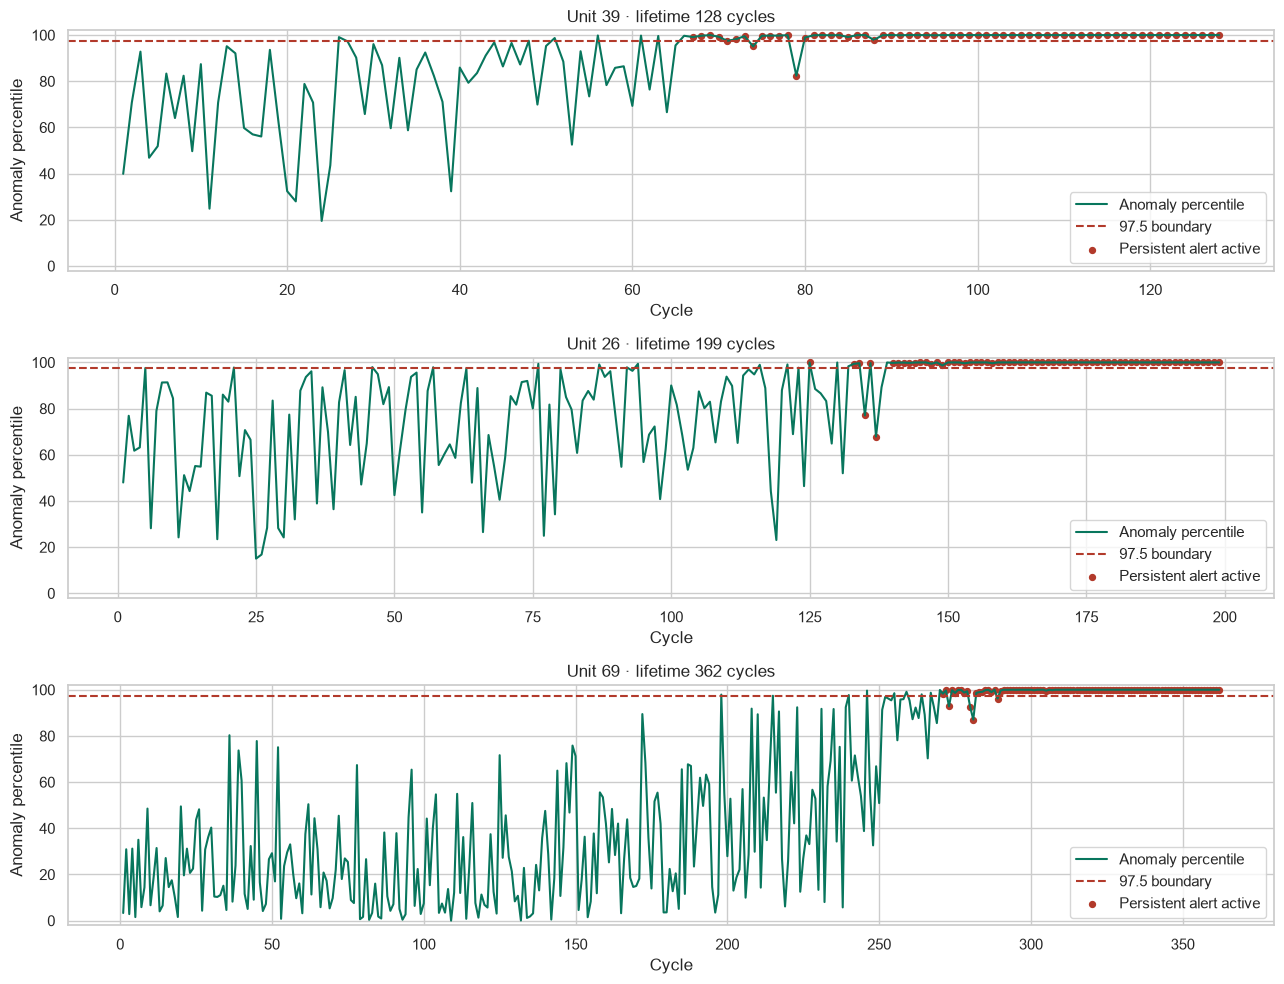

,unit_id,lifetime,first_persistent_alert_cycle,retrospective_lead_time
0,39,128,67,61
1,26,199,125,74
2,69,362,271,91


In [10]:
trajectory_units = [int(lifetimes.idxmin()), median_unit, int(lifetimes.idxmax())]
fig,axes=plt.subplots(3,1,figsize=(13,10),sharex=False)
timeline_summary=[]
for ax,unit in zip(axes,trajectory_units):
    track=df_scored[df_scored.unit_id==unit]
    ax.plot(track.cycle,track.percentile,color="#08765d",lw=1.5,label="Anomaly percentile")
    ax.axhline(97.5,color="#b23a2b",ls="--",label="97.5 boundary")
    active=track[track.persistent_alert]
    ax.scatter(active.cycle,active.percentile,s=18,color="#b23a2b",label="Persistent alert active")
    first=active.head(1)
    timeline_summary.append({"unit_id":unit,"lifetime":int(lifetimes[unit]),"first_persistent_alert_cycle":None if first.empty else int(first.cycle.iloc[0]),
                             "retrospective_lead_time":None if first.empty else int(first.raw_rul.iloc[0])})
    ax.set(title=f"Unit {unit} · lifetime {lifetimes[unit]} cycles",xlabel="Cycle",ylabel="Anomaly percentile",ylim=(-2,102))
    ax.legend(loc="lower right")
plt.tight_layout();plt.show()
display(pd.DataFrame(timeline_summary))

## 11. Future Production Output Contract

The future response should contain:

- `current_anomaly_score`
- `anomaly_percentile`
- `threshold_percentile`
- `current_threshold_exceeded`
- `recent_window_size`
- `recent_exceedance_count`
- `persistence_required_count`
- `persistence_window_size`
- `persistence_status`
- `alert_active`
- `history_cycle_count`
- `top_sensor_deviations`
- `model_version`
- `dataset`
- `development_stage`
- `warning`
- `disclaimer`

It must not expose `anomaly_probability`, `failure_probability`, `guaranteed_fault`, or safe/unsafe labels.

## 12. Stable Warning and Disclaimer

**Warning**

> Anomaly does not mean failure. Unusual sensor behavior may reflect degradation, operating variation, noise, or other causes and should be investigated in context.

**Disclaimer**

> Development-stage condition-monitoring estimate based on simulated NASA C-MAPSS FD001 data with one operating condition and one fault mode, a retrospective healthy-reference assumption, and no validated real-world anomaly labels. Not an industrial safety decision.

## 13. Future Metadata Specification

The later artifact metadata must include model name/version/family, dataset/subset, ordered predictors and count, normal-reference definition/row/unit counts, scaler specification, exact Isolation Forest parameters, score direction, full score-distribution summary, threshold quantile/raw score, empirical-CDF method, persistence window/required count, trajectory input contract, notebook 12 repeated-split stability and alert/lead-time findings, limitations, warning, disclaimer, package versions, and a timezone-aware training timestamp. The empirical reference score distribution—or an equivalent exact CDF representation—must accompany the detector for deterministic percentile inference.

In [11]:
PACKAGE_VERSIONS = {"python":platform.python_version(),"scikit_learn":sklearn.__version__,"numpy":np.__version__,"pandas":pd.__version__,"joblib":joblib.__version__}
metadata_specification = {
    "model_name":"FactoryMind Anomaly FD001 Isolation Forest", "model_version":MODEL_VERSION,
    "model_family":"IsolationForest", "dataset":"NASA C-MAPSS", "subset":"FD001",
    "predictor_columns":PREDICTOR_COLUMNS, "predictor_count":len(PREDICTOR_COLUMNS),
    "normal_reference_definition":"FD001 training rows with retrospective raw_rul > 125",
    "normal_reference_row_count":len(normal_reference), "normal_reference_unit_count":normal_reference.unit_id.nunique(),
    "scaler":{"class":"StandardScaler","with_mean":True,"with_std":True,"sensor_order":PREDICTOR_COLUMNS},
    "isolation_forest_hyperparameters":IF_HYPERPARAMETERS, "score_direction":"higher_is_more_anomalous via negative score_samples",
    "score_distribution_summary":score_summary.to_dict(), "threshold_quantile":THRESHOLD_QUANTILE,
    "threshold_raw_score":FINAL_RAW_THRESHOLD, "percentile_mapping_method":"right-inclusive empirical CDF of training-normal scores",
    "persistence_window":PERSISTENCE_WINDOW,"persistence_required_count":PERSISTENCE_REQUIRED,
    "input_trajectory_contract":["cycle"]+PREDICTOR_COLUMNS,
    "repeated_split_stability_notebook_12":{"spearman_mean":-0.6882,"spearman_std":0.0288,"spearman_min":-0.7293,"spearman_max":-0.6543},
    "known_limitations":["simulated data","one operating condition","one fault mode","no true anomaly labels","retrospective healthy proxy","no external validation"],
    "warning":WARNING,"disclaimer":DISCLAIMER,"package_versions":PACKAGE_VERSIONS,
    "training_timestamp_utc":datetime.now(timezone.utc).isoformat(),
}
display(pd.Series(PACKAGE_VERSIONS,name="version").to_frame())
print("Serialized sklearn estimators are version-sensitive; production loading must validate compatible package versions.")
display(pd.Series({k:v for k,v in metadata_specification.items() if k not in ["predictor_columns","score_distribution_summary","known_limitations"]}).to_frame("value"))

,version
python,3.13.2
scikit_learn,1.9.0
numpy,2.5.2
pandas,3.0.5
joblib,1.5.3


Serialized sklearn estimators are version-sensitive; production loading must validate compatible package versions.


,value
model_name,FactoryMind Anomaly FD001 Isolation Forest
model_version,1.0.0
model_family,IsolationForest
dataset,NASA C-MAPSS
subset,FD001
predictor_count,14
normal_reference_definition,FD001 training rows with retrospective raw_rul...
normal_reference_row_count,8031
normal_reference_unit_count,100
scaler,"{'class': 'StandardScaler', 'with_mean': True,..."


## 14. Final Leakage and Contract Audit

In [12]:
assert scaler.n_samples_seen_ == len(normal_reference)
assert detector.n_features_in_ == 14
assert not {"raw_rul","RUL","unit_id","cycle","target","failure"}.intersection(PREDICTOR_COLUMNS)
assert np.isclose(FINAL_RAW_THRESHOLD,np.quantile(normal_scores,.975))
assert np.array_equal(SORTED_NORMAL_SCORES,np.sort(normal_scores))
assert short_result["persistence_status"]=="insufficient_history" and not short_result["alert_active"]
assert TRAIN_PATH.name=="train_FD001.txt"
assert not any(Path("../models").glob("*anomaly*"))
print("PASS: final scaler and detector fit only 8,031 normal-reference rows.")
print("PASS: RUL, identity, cycle, targets, and labels are not predictors.")
print("PASS: threshold and percentile mapping derive only from final training-normal scores.")
print("PASS: persistence is backward-looking, requires five cycles, and uses exactly latest five.")
print("PASS: no official test labels loaded; no model artifact serialized; no tuning performed.")

PASS: final scaler and detector fit only 8,031 normal-reference rows.
PASS: RUL, identity, cycle, targets, and labels are not predictors.
PASS: threshold and percentile mapping derive only from final training-normal scores.
PASS: persistence is backward-looking, requires five cycles, and uses exactly latest five.
PASS: no official test labels loaded; no model artifact serialized; no tuning performed.


## Frozen Anomaly Detection v1 Specification

- **Model:** Raw Isolation Forest
- **Predictors:** 14 retained C-MAPSS sensors
- **Normal reference:** FD001 training observations with retrospective `raw_rul > 125`
- **Scaling:** StandardScaler fitted only on normal-reference observations
- **Score:** Higher means more anomalous (`-score_samples`)
- **User-facing score:** Training-normal right-inclusive empirical percentile, 0–100, not probability
- **Alert boundary:** 97.5th percentile of the final fitted training-normal score distribution
- **Persistence:** At least 3 of the latest 5 cycles above the boundary
- **Minimum persistence history:** 5 consecutive cycles
- **Short history:** Score and current exceedance available; persistent alert unavailable
- **Alert semantics:** Current threshold state plus persistent alert state; no invented severity categories
- **Explanation:** Top standardized sensor deviations relative to the normal reference
- **Uncertainty:** No calibrated anomaly probability
- **External validation:** None

### Production-refactor readiness

**A) Frozen anomaly v1 specification is ready for guarded production-code refactor.**

This is readiness to implement the frozen development specification—not a claim of industrial production readiness or safety validation.

Recommended next implementation step: create `src/anomaly_features.py`, `src/anomaly_pipeline.py`, and `src/anomaly_train.py` with focused tests in a future task. Do not create them here.